In [ ]:
from tensorflow import keras
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation, SpatialDropout2D,
                                    AveragePooling2D, DepthwiseConv2D, SeparableConv2D,
                                    Flatten, Dense, Dropout, Add, Permute, Reshape, LayerNormalization,Concatenate,Layer,concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm, MinMaxNorm
import keras_nlp
import tensorflow as tf
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import layers, models, constraints



In [ ]:
class TrainableAlphaConcat(Layer):
    def __init__(self, num_blocks=6, initial_value=1.0, **kwargs):
        super().__init__(**kwargs)
        self.num_blocks = num_blocks
        self.alphas = self.add_weight(
            name="alpha_weights",
            shape=(1, 1, 1, num_blocks),
            initializer=tf.keras.initializers.Constant(initial_value),
            trainable=True,

            constraint=tf.keras.constraints.MinMaxNorm(min_value=0.0, max_value=1.0)
        )

    def call(self, inputs):
        # Stack inputs along the last axis to create a single tensor
        inputs_tensor = tf.stack(inputs, axis=-1)  # Shape: (batch, 32, 1000, num_blocks, 8)
        print(f" alpfa 6 inputs_tensor shape: {inputs_tensor.shape}")

        # Multiply each block with its corresponding alpha
        weighted_blocks = inputs_tensor * self.alphas  # Broadcasts correctly

        # Concatenate along feature dimension
        return tf.concat(tf.unstack(weighted_blocks, axis=-1), axis=-1)  # (batch, 32, 1000, num_blocks * 8)

In [ ]:
from tensorflow.keras.layers import Layer, concatenate
import tensorflow as tf
from tensorflow.keras import constraints

class TrainableAlpha(Layer):
    def __init__(self, initial_value1=0.8,initial_value2=0.2, **kwargs):
        super().__init__(**kwargs)
        self.alpha = self.add_weight(
            name="alpha_weight",
            shape=(),
            initializer=tf.keras.initializers.Constant(initial_value1),
            trainable=True,

            constraint=tf.keras.constraints.MinMaxNorm(min_value=0.0, max_value=1.0)
        )
        self.beta = self.add_weight(
            name="beta_weight",
            shape=(),
            initializer=tf.keras.initializers.Constant(initial_value2),
            trainable=True,

            constraint=tf.keras.constraints.MinMaxNorm(min_value=0.0, max_value=1.0)
        )

    def call(self, inputs):
        temporal_features, transformer_output = inputs
        return concatenate([
            temporal_features * self.alpha,
            transformer_output * (self.beta)
        ], axis=3)

In [ ]:
def best_sofardil( nb_classes=2, Chans=32, Samples=1000,
                            dropoutRate=0.3, F1=8, D=2, F2=16,
                            norm_rate=0.25, dropoutType='Dropout'):
            if dropoutType == 'SpatialDropout2D':
                dropoutType = SpatialDropout2D
            elif dropoutType == 'Dropout':
                dropoutType = Dropout
            else:
                raise ValueError('dropoutType must be one of SpatialDropout2D or Dropout')

            # Input layer
            input1 = Input(shape=(Chans, Samples, 1), name='input1')

            # Stream 1: Multi-scale Temporal Convolutions
            kernel_sizes = [5, 9, 13, 29, 61, 125]
            temporal_blocks = []
            N=1

            for i, k_size in enumerate(kernel_sizes):
                temp_conv = Conv2D(F1, (N, k_size), padding='same',
                                use_bias=False, name=f'temporal_conv_{i}')(input1)
                temp_conv = BatchNormalization(name=f'temporal_bn_{i}')(temp_conv)
                temp_conv = Activation('elu', name=f'temporal_act_{i}')(temp_conv)
                temp_conv=SpatialDropout2D(0.50)(temp_conv)
                temporal_blocks.append(temp_conv)



            temporal_features = TrainableAlphaConcat(num_blocks=len(temporal_blocks))(temporal_blocks)

            # Stream 2: Simplified transformer with residual
            transformer_input = Permute((2, 1, 3))(input1)
            shape = transformer_input.shape
            transformer_input = Reshape((shape[1], shape[2]))(transformer_input)
            original_input = transformer_input

            transformer_output = keras_nlp.layers.TransformerEncoder(
                intermediate_dim=32,
                num_heads=2,
                dropout=0.2 ,
                activation='gelu'
            )(transformer_input)

            # residual connection
            """
            Input → Transform → Output
                ↘_________________↗
                Direct connection (residual)
            """
            transformer_output = Add()([transformer_output, original_input])

            transformer_output = Reshape((Chans, Samples, 1))(transformer_output)

            merged = TrainableAlpha()( [temporal_features, transformer_output] )

            merged = LayerNormalization()(merged)

            # Spatial Processing
            spatial = DepthwiseConv2D((Chans, 1), use_bias=False,
                                    depth_multiplier=D,
                                    depthwise_constraint=max_norm(1.),
                                    name='spatial_conv')(merged)
            spatial = BatchNormalization(name='spatial_bn')(spatial)

            spatial = Activation('elu', name='spatial_act')(spatial)

            spatial = AveragePooling2D((1, 4), name='spatial_pool')(spatial)
            spatial = dropoutType(dropoutRate, name='spatial_drop')(spatial)


            # Separable Convolutions
            separator = SeparableConv2D(F2, (1, 16), use_bias=False,
                                    padding='same', name='separator')(spatial)
            separator = BatchNormalization(name='separator_bn')(separator)
            separator = Activation('elu', name='separator_act')(separator)
            separator = AveragePooling2D((1, 8), name='separator_pool')(separator)
            separator = dropoutType(dropoutRate, name='separator_drop')(separator)

            # Classification Head
            flatten = Flatten(name='flatten')(separator)
            dense = Dense(nb_classes, name='dense1',
                        kernel_constraint=max_norm(norm_rate))(flatten)
            softmax = Activation('softmax', name='softmax')(dense)

            return Model(inputs=input1, outputs=softmax)

**Initialize And train the model on subject's 6 session 1**

In [ ]:
model=best_sofardil()


###### Add the Training code

#
#
#
#
#
#
#
#
#


 alpfa 6 inputs_tensor shape: (None, 32, 1000, 8, 6)


**Load the weights of the train model forthe subject 6**

In [ ]:
model.load_weights('best_model_weights (31).h5') # Put the name of the file with the trained model weights

In [ ]:
model.summary(expand_nested=True,line_length=120) # Print the model summary

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ input1 (InputLayer)               │ (None, 32, 1000, 1)          │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_conv_0 (Conv2D)          │ (None, 32, 1000, 8)          │                40 │ input1[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_conv_1 (Conv2D)          │ (None, 32, 1000, 8)          │                72 │ input1[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_conv_2 (Conv2D)          │ (None, 32, 1000, 8)          │               104 │ input1[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_conv_3 (Conv2D)          │ (None, 32, 1000, 8)          │               232 │ input1[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_conv_4 (Conv2D)          │ (None, 32, 1000, 8)          │               488 │ input1[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_conv_5 (Conv2D)          │ (None, 32, 1000, 8)          │             1,000 │ input1[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ permute_18 (Permute)              │ (None, 1000, 32, 1)          │                 0 │ input1[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_bn_0                     │ (None, 32, 1000, 8)          │                32 │ temporal_conv_0[0][0]     
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_bn_1                     │ (None, 32, 1000, 8)          │                32 │ temporal_conv_1[0][0]     
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_bn_2                     │ (None, 32, 1000, 8)          │                32 │ temporal_conv_2[0][0]     
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_bn_3                     │ (None, 32, 1000, 8)          │                32 │ temporal_conv_3[0][0]     
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_bn_4                     │ (None, 32, 1000, 8)          │                32 │ temporal_conv_4[0][0]     
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ temporal_bn_5                     │ (None, 32, 1000, 8

 Total params: 16,516 (64.52 KB)

 Trainable params: 16,192 (63.25 KB)

 Non-trainable params: 324 (1.27 KB)

train_labels_categorical shape: (93, 2)
 alpfa 6 inputs_tensor shape: (None, 32, 1000, 8, 6)
spatial shape: (None, 1, 1000, 98)
separator shape: (None, 1, 250, 16)
Epoch 1/50
 alpfa 6 inputs_tensor shape: (None, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (None, 32, 1000, 8, 6)
6/6 ━━━━━━━━━━━━━━━━━━━━ 70s 8s/step - accuracy: 0.5485 - loss: 0.6736
Epoch 2/50


KeyboardInterrupt: 

**Load the data from the testing session 4 of the subject 6**

In [ ]:
import scipy.io as sio
import numpy as np

def load_data_and_labels(file_path):
  """Loads data and labels from a .mat file and converts labels to 0 and 1.

  Args:
    file_path: Path to the .mat file.

  Returns:
    A tuple containing the data and labels.
  """
  mat_data = sio.loadmat(file_path)
  data = mat_data['data']
  labels = mat_data['labels']

  # Convert labels to 0 and 1
  labels = labels - 1

  return data, labels

# Example usage:
file_path = "sub-006_ses-04_task_motorimagery_eeg.mat"
data, labels = load_data_and_labels(file_path)

# Now you can use the 'data' and 'labels' for testing your model
# ...

In [ ]:
print(data.shape)
print(labels.shape)

(92, 32, 1000)
(1, 92)


**Check the model accurracy on testing session 4**

In [ ]:

correct_predictions = 0
total_trials = data.shape[0]

for i in range(total_trials):  # Loop through each trial (first dimension)
  # Get the first trial's data and label
  first_trial_data = data[i]  # Get the first trial (index i)
  first_trial_label = labels[0, i]  # Get the corresponding label (first element)

  # Reshape the data to match the model's input shape (1, Chans, Samples, 1)
  first_trial_data = first_trial_data.reshape(1, first_trial_data.shape[0], first_trial_data.shape[1], 1)

  # Make a prediction for the trial
  prediction = model.predict(first_trial_data)

  # Get the predicted class label (0 or 1)
  predicted_label = np.argmax(prediction, axis=1)[0]

  # Compare predicted label with the true label
  if predicted_label == first_trial_label:
    correct_predictions += 1

# Calculate the overall accuracy
accuracy = correct_predictions / total_trials

# Print the overall accuracy
print(f"Overall Accuracy: {accuracy:.4f}")

 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━

In [ ]:
# ... (your previous code for loading data and model) ...

# Get the first trial's data and label
first_trial_data = data[43]  # Get the first trial (index 0)
first_trial_label = labels[0, 43]  # Get the corresponding label (first element)

# Reshape the data to match the model's input shape (1, Chans, Samples, 1)
first_trial_data = first_trial_data.reshape(1, first_trial_data.shape[0], first_trial_data.shape[1], 1)

# Make a prediction for the first trial
prediction = model.predict(first_trial_data)
print(f"predictionnnnnnnnnnnnnnnnnnnn {prediction}")
# Get the predicted class label (0 or 1)
predicted_label = np.argmax(prediction, axis=1)[0]

# # Print the prediction and true label
print(f"Predicted label: {predicted_label}")
print(f"True label: {first_trial_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
predictionnnnnnnnnnnnnnnnnnnn [[0.06784184 0.9321582 ]]
Predicted label: 1
True label: 1


In [ ]:
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 1.7 MB/s eta 0:00:00


In [ ]:
import tf_keras_vis
print(tf_keras_vis.__version__)

0.8.7


**Check Inputs x Gradients interpratation method for a single MI trial**

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ------------------------------
# 1. Load model and input sample
# ------------------------------
# model = best_sofardil()
# model.load_weights('best_model_weights.h5')  # replace with your actual path
first_trial_data = data[43]  # Get the first trial (index i)
first_trial_label = labels[0, 43]
first_trial_data = first_trial_data.reshape(1, first_trial_data.shape[0], first_trial_data.shape[1], 1)

x_sample = first_trial_data  # shape: (1, 32, 1000, 1)

# -------------------------------------
# 2. Compute Input × Gradient heatmap
# -------------------------------------
# 2.1 Get pre-softmax (logits) model
logits_model = tf.keras.Model(inputs=model.input, outputs=model.layers[-2].output)

# 2.2 Prepare input
x_tensor = tf.convert_to_tensor(x_sample, dtype=tf.float32)
x_tensor = tf.Variable(x_tensor)

# 2.3 Compute gradients wrt predicted class logit
with tf.GradientTape() as tape:
    tape.watch(x_tensor)
    logits = logits_model(x_tensor, training=False)  # BatchNorm in inference mode
    preds_softmax = tf.nn.softmax(logits)
    pred_class = tf.argmax(preds_softmax[0])
    class_score = logits[:, pred_class]

grads = tape.gradient(class_score, x_tensor)
input_x_grad = x_tensor.numpy() * grads.numpy()  # shape: (1, 32, 1000, 1)
heatmapvis = input_x_grad[0, :, :, 0]            # shape: (32, 1000)

# Normalize for visualization
heatmapvis -= heatmapvis.mean()
heatmapvis /= (heatmapvis.std() + 1e-5)

# -------------------------------------
# 3. Visualize the heatmap
# -------------------------------------
plt.figure(figsize=(15, 8))
plt.imshow(heatmapvis, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title(f"Input × Gradient for class {pred_class.numpy()}")
plt.xlabel('Time')
plt.ylabel('Channels')
plt.show()


 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)


In [ ]:
!pip install mne

heatmapvis shape: (32, 1000)
avg_data shape: (32,)


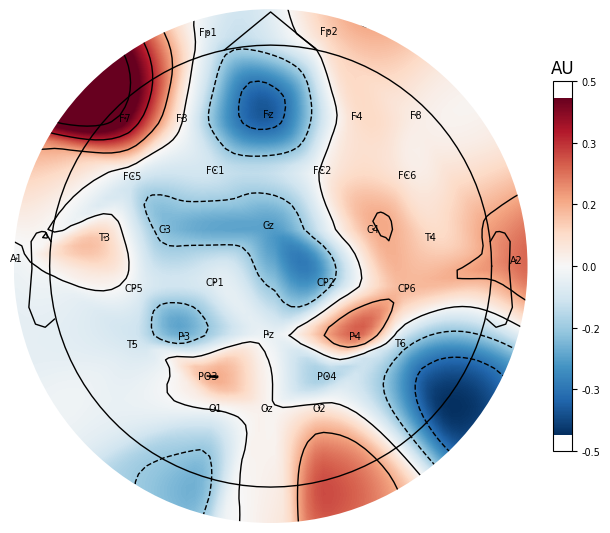

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# === Input: your heatmap data ===
# Example: heatmapvis shape should be (n_trials, 32, 1000)
# For this example, simulate it:
# heatmapvis = np.random.randn(100, 32, 1000)
print(f"heatmapvis shape: {heatmapvis.shape}")
avg_data = np.array(heatmapvis).mean(axis=1)  # mean over trials and time → shape (32,)
print("avg_data shape:", avg_data.shape)  # should be (32,)

# Simulate your EEG data (replace this with your actual data)
eeg_data = heatmapvis  # Shape: (n_channels, n_times)

# Channel names
ch_names = ["Fp1", "Fp2", "Fz", "F3", "F4", "F7", "F8", "FC1", "FC2", "FC5",
            "FC6", "Cz", "C3", "C4", "T3", "T4", "A1", "A2", "CP1", "CP2",
            "CP5", "CP6", "Pz", "P3", "P4", "T5", "T6", "PO3", "PO4", "Oz",
            "O1", "O2"]

sfreq = 250  # Hz
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types="eeg")

# Create Evoked object from averaged data across time
mean_values = eeg_data.mean(axis=1)  # shape (32,)

# Turn it into a fake Evoked object
evoked = mne.EvokedArray(mean_values[:, np.newaxis], info)
montage = mne.channels.make_standard_montage('standard_1005')
evoked.set_montage(montage)

fig = evoked.plot_topomap(times=0, scalings=1, show_names=True, time_format='',size=4, colorbar=True, show=False)
plt.show()


**Agregated Visualization and Inputs x Gradients per class**


In [ ]:
#Agregated Visualization per class

import tensorflow as tf
import numpy as np
import mne
import matplotlib.pyplot as plt

# Assuming:
# - data shape: (n_trials, n_channels, n_times)
# - labels shape: (2, n_trials) or (n_trials,) depending on your label format
# - model is your trained keras model
print(f"shape labels: {labels.shape}")

n_trials = data.shape[0]
n_channels = data.shape[1]
n_times = data.shape[2]

# Output layer before softmax (logits)
logits_model = tf.keras.Model(inputs=model.input, outputs=model.layers[-2].output)

# Containers to collect input x grad for each class
class0_maps = []
class1_maps = []

for i in range(n_trials):
    x_sample = data[i].reshape(1, n_channels, n_times, 1).astype(np.float32)
    x_tensor = tf.Variable(x_sample)

    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        logits = logits_model(x_tensor, training=False)
        preds_softmax = tf.nn.softmax(logits)
        pred_class = tf.argmax(preds_softmax[0])
        class_score = logits[:, pred_class]

    grads = tape.gradient(class_score, x_tensor)
    input_x_grad = (x_tensor * grads).numpy()[0, :, :, 0]  # shape (32, 1000)

    # Normalize map for this trial (optional but recommended)
    input_x_grad -= input_x_grad.mean()
    input_x_grad /= (input_x_grad.std() + 1e-5)

    # Determine the true class label for trial i (adjust indexing depending on your label shape)
    # For example if labels shape is (n_trials,) and classes are 0 or 1:

    trial_label = labels[0,i]  # or labels[0,i] if 2D
    if trial_label == 0 and pred_class==0: #i putted and to check only for the correctly classified
        class0_maps.append(input_x_grad)
    elif  trial_label == 1 and pred_class==1:
        class1_maps.append(input_x_grad)

# Convert lists to arrays
class0_maps = np.array(class0_maps)  # shape (n_class0_trials, 32, 1000)
class1_maps = np.array(class1_maps)  # shape (n_class1_trials, 32, 1000)


shape labels: (1, 92)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape

In [ ]:
# Average over trials and time
print(f"shape class0_maps: {class0_maps.shape}")
print(f"shape class1_maps: {class1_maps.shape}")
class0_avg = class0_maps.mean(axis=0)  # shape (32,)
class1_avg = class1_maps.mean(axis=0)  # shape (32,)

print(f"class0_avg shape: {class0_avg.shape}")
print(f"class1_avg shape: {class1_avg.shape}")



shape class0_maps: (41, 32, 1000)
shape class1_maps: (42, 32, 1000)
class0_avg shape: (32, 1000)
class1_avg shape: (32, 1000)


**Aggregated maps for all trials per class**

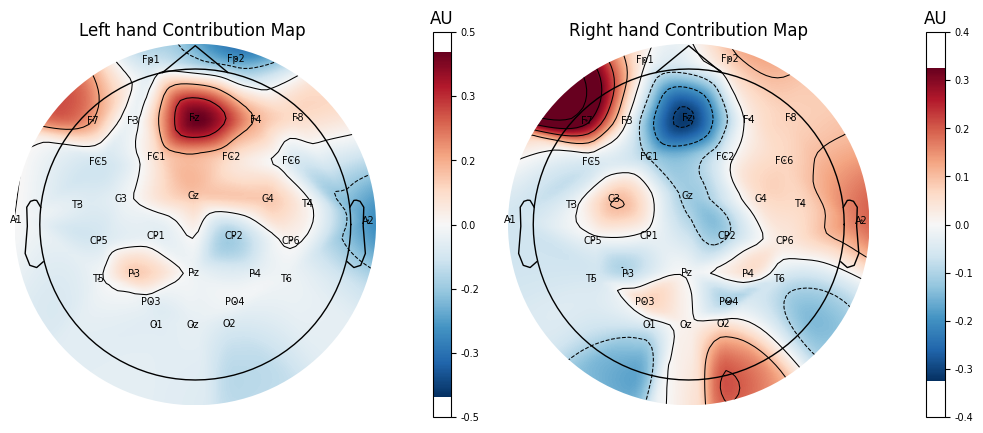

In [ ]:
import matplotlib.pyplot as plt
import mne
from matplotlib.gridspec import GridSpec

# Setup info and montage once
ch_names = ["Fp1", "Fp2", "Fz", "F3", "F4", "F7", "F8", "FC1", "FC2", "FC5",
            "FC6", "Cz", "C3", "C4", "T3", "T4", "A1", "A2", "CP1", "CP2",
            "CP5", "CP6", "Pz", "P3", "P4", "T5", "T6", "PO3", "PO4", "Oz",
            "O1", "O2"]
sfreq = 250
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types="eeg")
montage = mne.channels.make_standard_montage('standard_1005')
info.set_montage(montage)
avg_data0 = class0_avg.mean(axis=1)
avg_data1 = class1_avg.mean(axis=1)
# Create evoked objects
evoked0 = mne.EvokedArray(avg_data0[:, np.newaxis], info)
evoked0.set_montage(montage)
evoked1 = mne.EvokedArray(avg_data1[:, np.newaxis], info)
evoked1.set_montage(montage)

# Create figure and gridspec for two plots with colorbars each
fig = plt.figure(figsize=(12, 5))
gs = GridSpec(1, 4, figure=fig, width_ratios=[20, 1, 20, 1], wspace=0.3)

# Left plot and colorbar axes
ax0_topomap = fig.add_subplot(gs[0])
ax0_cbar = fig.add_subplot(gs[1])

# Right plot and colorbar axes
ax1_topomap = fig.add_subplot(gs[2])
ax1_cbar = fig.add_subplot(gs[3])

# Plot each evoked topomap with its own colorbar axis
evoked0.plot_topomap(times=0, scalings=1, show_names=True, time_format='', size=3,
                     axes=[ax0_topomap, ax0_cbar], colorbar=True, show=False)
ax0_topomap.set_title('Left hand Contribution Map ')

evoked1.plot_topomap(times=0, scalings=1, show_names=True, time_format='', size=3,
                     axes=[ax1_topomap, ax1_cbar], colorbar=True, show=False)
ax1_topomap.set_title('Right hand Contribution Map')

plt.show()


**Series of toolmaps animated over time to see the temporal dynamics like the contribution of the electrodes over time:**

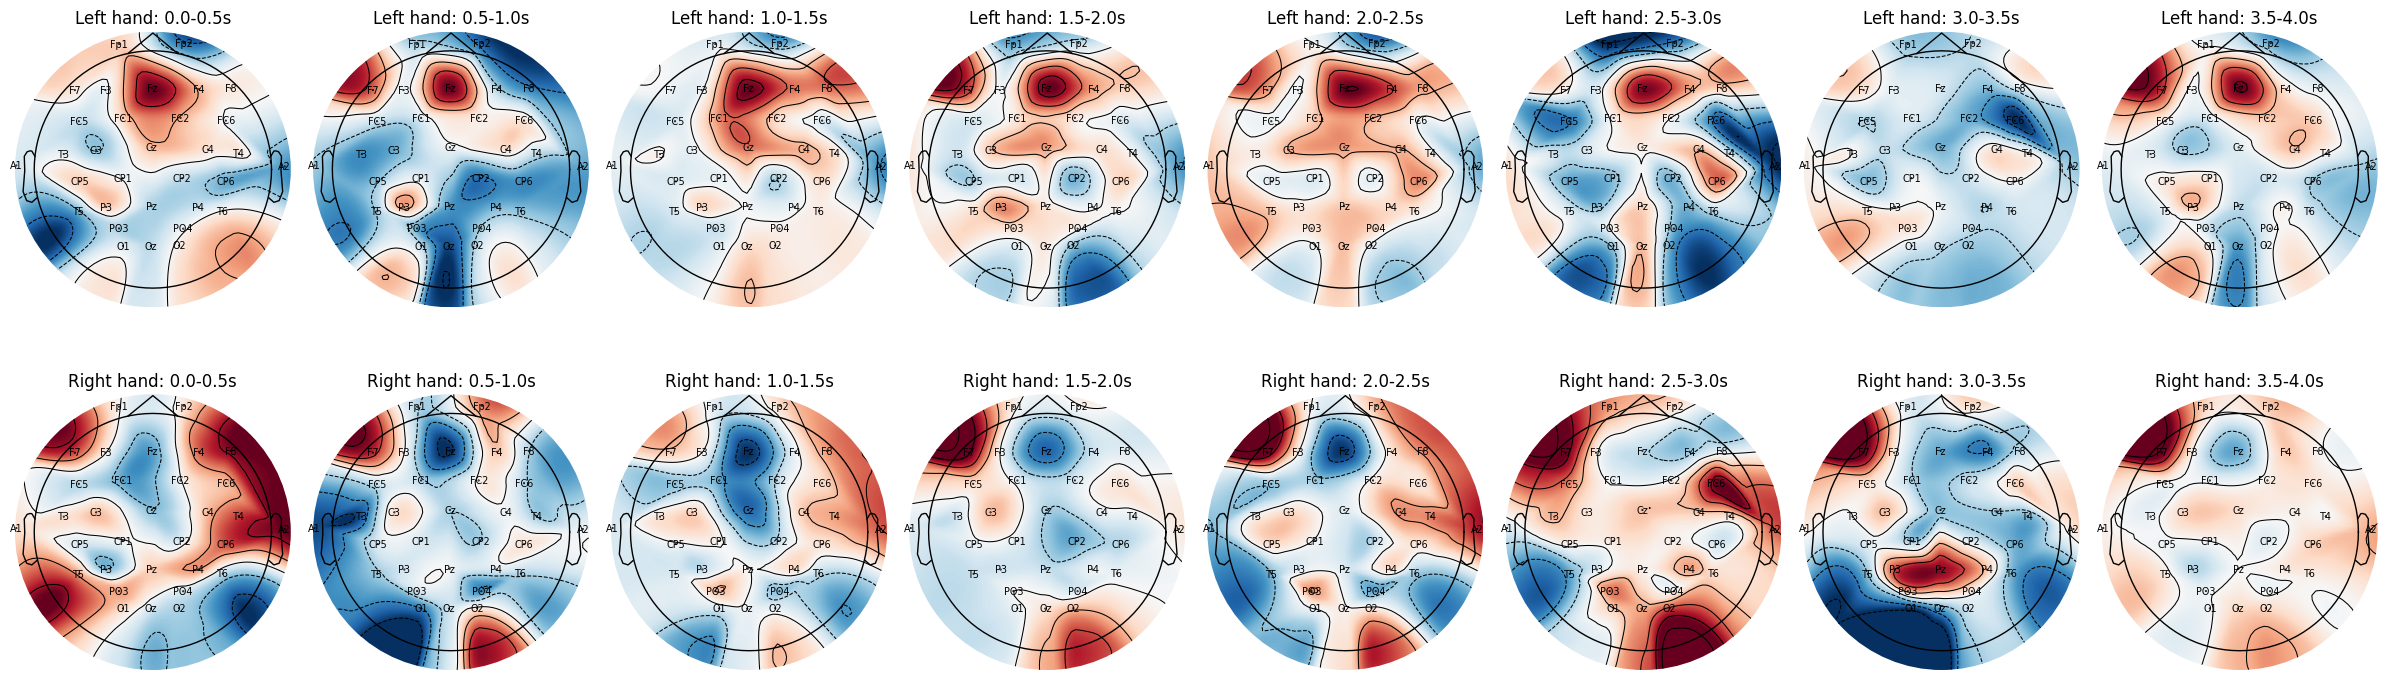

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import mne

# Assuming class0_avg and class1_avg both shape (32, 1000), sfreq=250
sfreq = 250
window_sec = 0.5
window_samples = int(window_sec * sfreq)  # 125 samples per window

ch_names = ["Fp1", "Fp2", "Fz", "F3", "F4", "F7", "F8", "FC1", "FC2", "FC5",
            "FC6", "Cz", "C3", "C4", "T3", "T4", "A1", "A2", "CP1", "CP2",
            "CP5", "CP6", "Pz", "P3", "P4", "T5", "T6", "PO3", "PO4", "Oz",
            "O1", "O2"]
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1005')
info.set_montage(montage)

n_windows = class0_avg.shape[1] // window_samples  # assuming both have same shape

fig, axes = plt.subplots(2, n_windows, figsize=(3 * n_windows, 8))

for i in range(n_windows):
    start = i * window_samples
    end = start + window_samples

    # Class 0 average in window
    avg_data0 = class0_avg[:, start:end].mean(axis=1)
    evoked0 = mne.EvokedArray(avg_data0[:, np.newaxis], info)
    evoked0.set_montage(montage)
    evoked0.plot_topomap(times=0, axes=axes[0, i], show_names=True, time_format='',
                         scalings=1, size=3, colorbar=False, show=False)
    axes[0, i].set_title(f'Left hand: {i*window_sec:.1f}-{(i+1)*window_sec:.1f}s')

    # Class 1 average in window
    avg_data1 = class1_avg[:, start:end].mean(axis=1)
    evoked1 = mne.EvokedArray(avg_data1[:, np.newaxis], info)
    evoked1.set_montage(montage)
    evoked1.plot_topomap(times=0, axes=axes[1, i], show_names=True, time_format='',
                         scalings=1, size=3, colorbar=False, show=False)
    axes[1, i].set_title(f'Right hand: {i*window_sec:.1f}-{(i+1)*window_sec:.1f}s')

plt.tight_layout()
plt.show()



**Agregated Trust test of the interpretation -- Per class Agregated Trust test And Global (agregated for both classes by averaging the per class attribution maps)** (only on correctly predicted trials)

shape of labels: (1, 92)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor sh

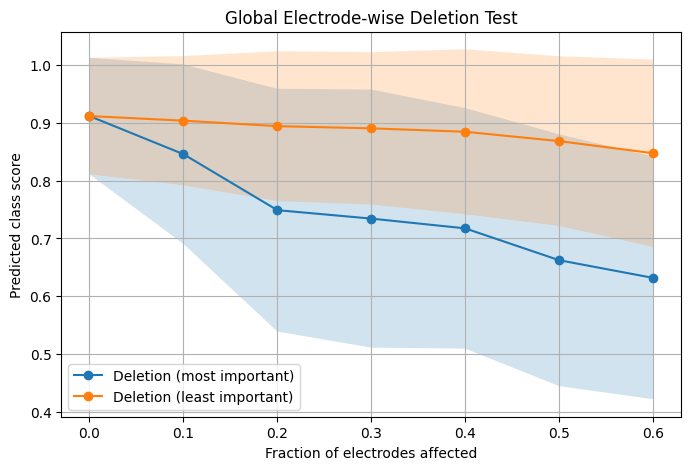

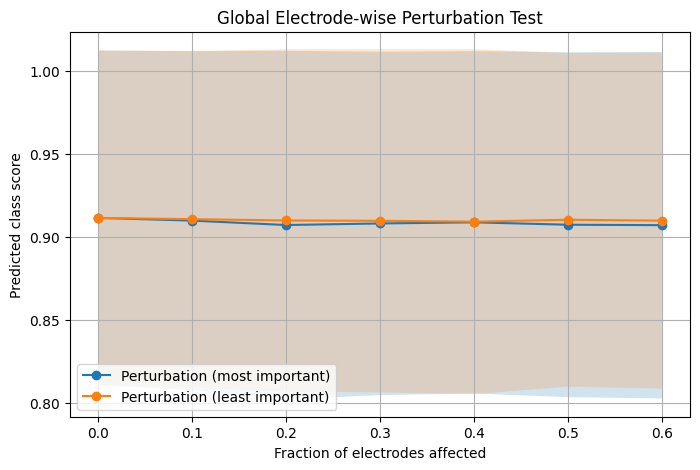


--- Class 0 ---


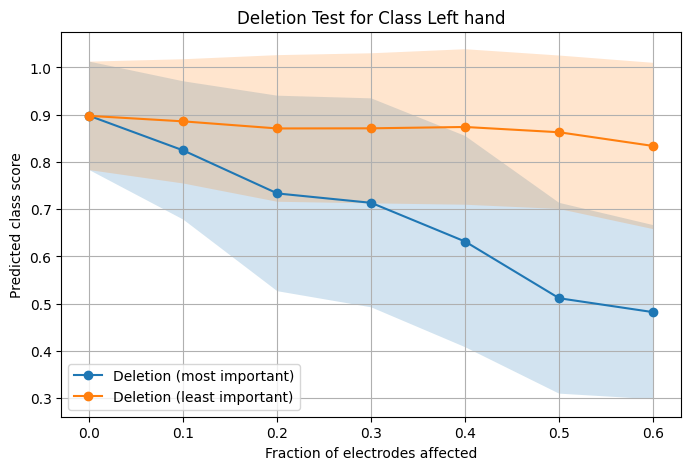

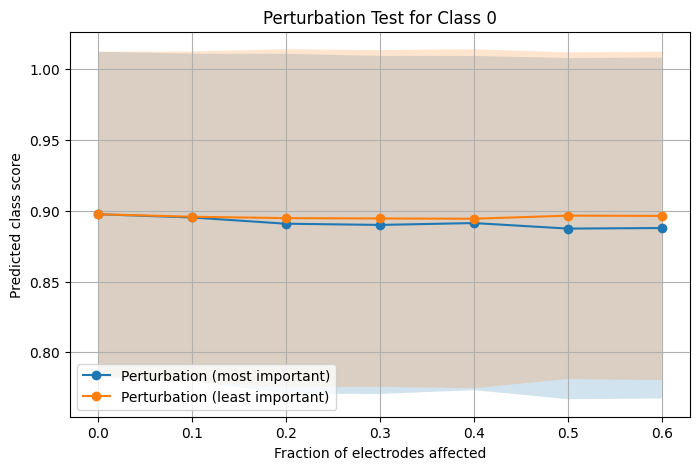


--- Class 1 ---


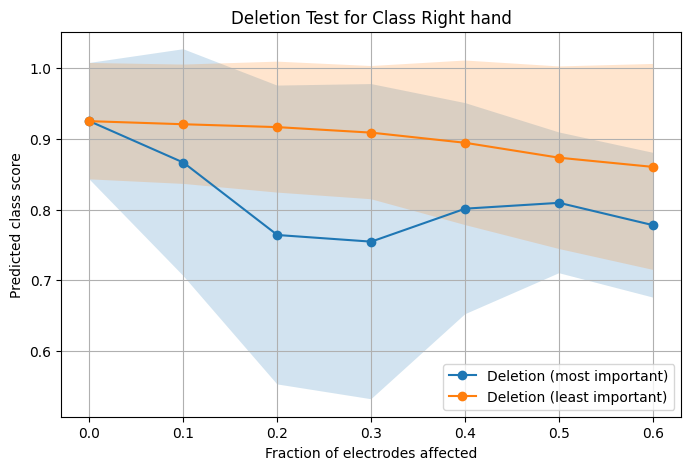

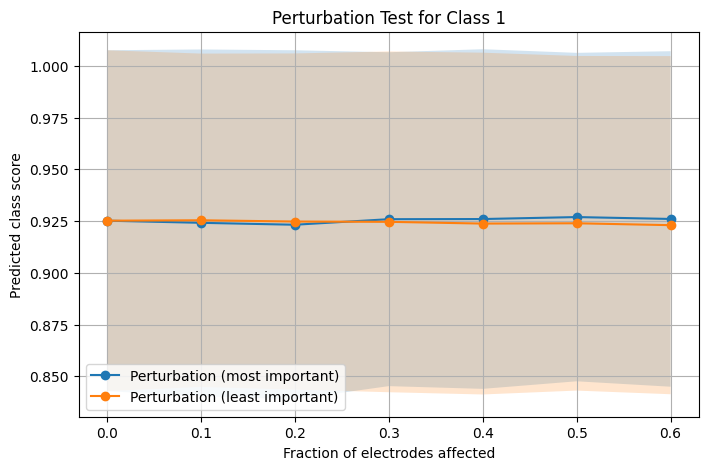

shape of labels: (1, 92)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor shape: (1, 32, 1000, 8, 6)
 alpfa 6 inputs_tensor sh

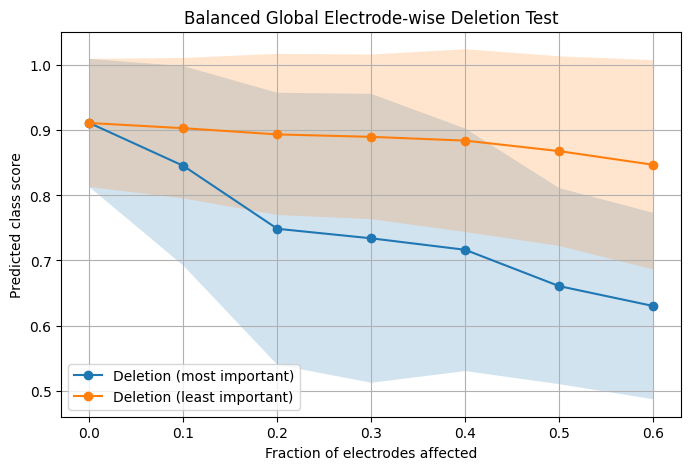

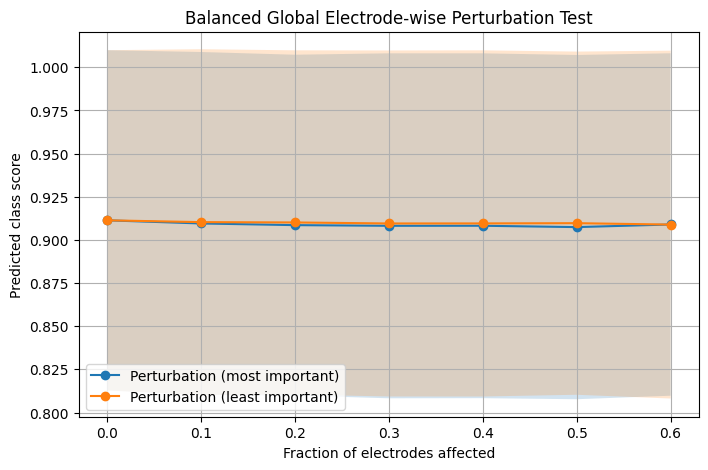


--- Class 0 ---


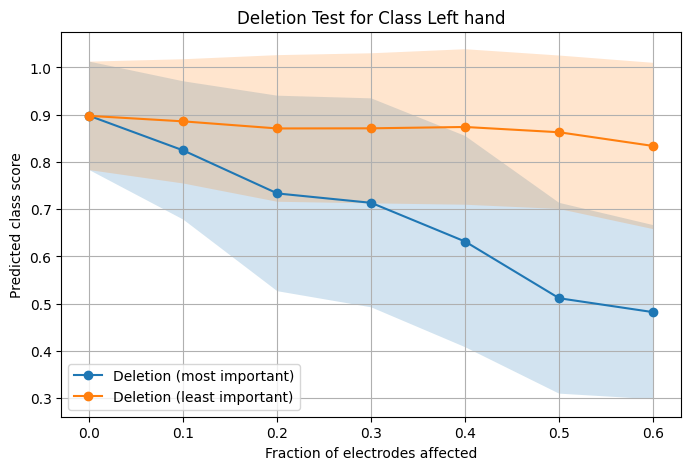

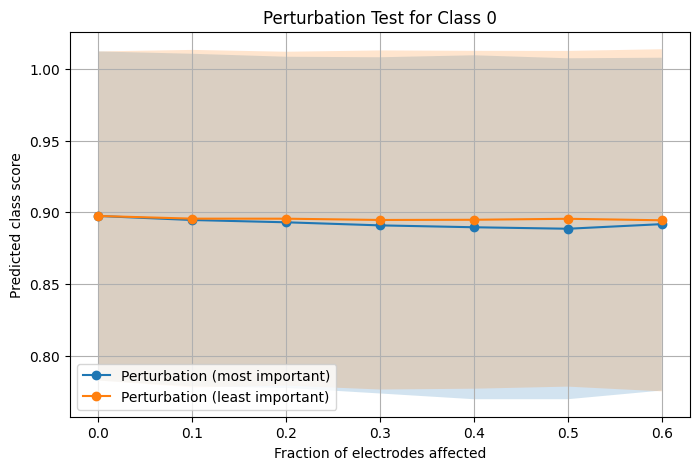


--- Class 1 ---


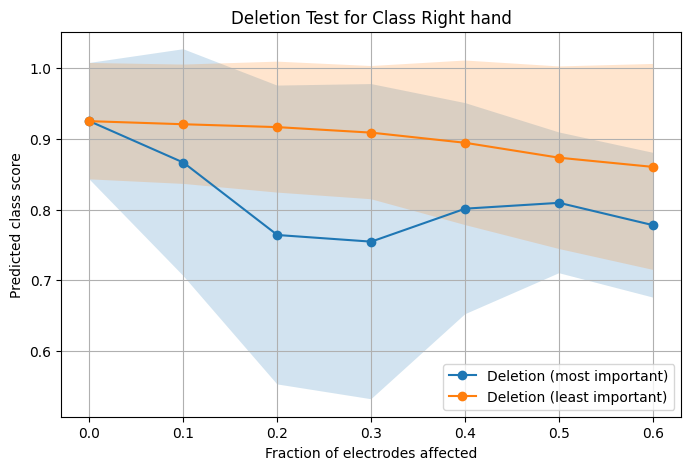

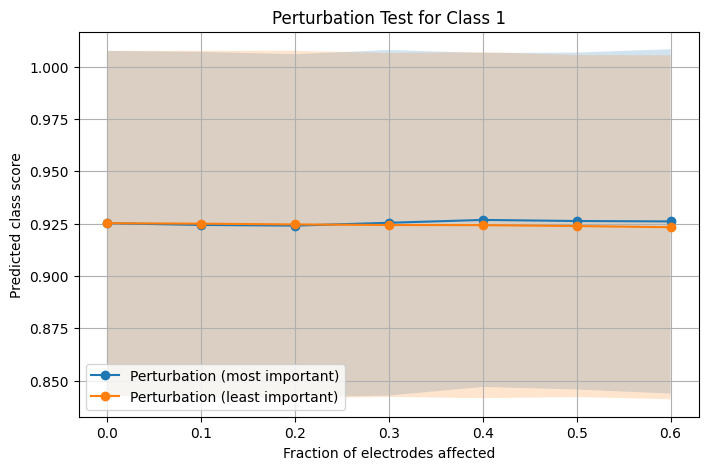

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import defaultdict
print(f"shape of labels: {labels.shape}")

# Configs
percentages = np.arange(0, 0.61, 0.1)
n_trials, n_electrodes, n_timepoints = data.shape
unique_classes = np.unique(labels)

# Storage for global results
global_scores = {
    "deletion": [],

    "worst_deletion": [],

}

# Storage for per-class results
per_class_scores = {
    cls: {
        "deletion": [],

        "worst_deletion": [],

    } for cls in unique_classes
}

for trial in range(n_trials):
    x_sample = data[trial].reshape(1, n_electrodes, n_timepoints, 1)
    true_class = labels[0, trial]

    # --- Check if model predicted correctly
    logits_check = model(tf.convert_to_tensor(x_sample, dtype=tf.float32), training=False).numpy()
    predicted_class = np.argmax(logits_check[0])
    if predicted_class != true_class:
        continue  # Skip incorrectly predicted trials

    # --- Attribution map for this sample
    logits_model = tf.keras.Model(inputs=model.input, outputs=model.layers[-2].output)
    x_tensor = tf.convert_to_tensor(x_sample, dtype=tf.float32)
    x_tensor = tf.Variable(x_tensor)

    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        logits = logits_model(x_tensor, training=False)
        preds_softmax = tf.nn.softmax(logits)
        pred_class = tf.argmax(preds_softmax[0])
        class_score = logits[:, pred_class]

    grads = tape.gradient(class_score, x_tensor)
    input_x_grad = x_tensor.numpy() * grads.numpy()
    heatmapvis = input_x_grad[0, :, :, 0]

    electrode_importance = np.abs(heatmapvis).mean(axis=1)
    sorted_electrodes = np.argsort(electrode_importance)[::-1]
    worst_sorted_electrodes = np.argsort(electrode_importance)

    def deletion_test(ranking):
        scores = []
        for perc in percentages:
            x_deleted = x_sample.copy()
            n_delete = int(perc * n_electrodes)
            electrodes_to_delete = ranking[:n_delete]
            x_deleted[0, electrodes_to_delete, :, 0] = 0
            pred = model(tf.convert_to_tensor(x_deleted, dtype=tf.float32), training=False).numpy()[0, pred_class.numpy()]
            scores.append(pred)
        return scores



    # Append to global
    global_scores["deletion"].append(deletion_test(sorted_electrodes))

    global_scores["worst_deletion"].append(deletion_test(worst_sorted_electrodes))


    # Append to per-class
    per_class_scores[true_class]["deletion"].append(global_scores["deletion"][-1])

    per_class_scores[true_class]["worst_deletion"].append(global_scores["worst_deletion"][-1])

# --- Plot Global Results
def plot_scores(mean_scores, std_scores, title, ylabel, label1, label2):
    plt.figure(figsize=(8, 5))
    plt.plot(percentages, mean_scores[0], '-o', label=label1)
    plt.fill_between(percentages, mean_scores[0] - std_scores[0], mean_scores[0] + std_scores[0], alpha=0.2)
    plt.plot(percentages, mean_scores[1], '-o', label=label2)
    plt.fill_between(percentages, mean_scores[1] - std_scores[1], mean_scores[1] + std_scores[1], alpha=0.2)
    plt.xlabel('Fraction of electrodes affected')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

def compute_mean_std(scores_list):
    arr1 = np.array(scores_list[0])  # important
    arr2 = np.array(scores_list[1])  # least important
    return [arr1.mean(axis=0), arr2.mean(axis=0)], [arr1.std(axis=0), arr2.std(axis=0)]
def compute_balanced_global_mean_std(per_class_scores_dict, key1, key2):
    class_means_1, class_means_2 = [], []
    class_stds_1, class_stds_2 = [], []

    for cls in unique_classes:
        data1 = np.array(per_class_scores_dict[cls][key1])
        data2 = np.array(per_class_scores_dict[cls][key2])
        if len(data1) == 0 or len(data2) == 0:
            continue  # Skip class if no correctly predicted samples

        class_means_1.append(data1.mean(axis=0))
        class_means_2.append(data2.mean(axis=0))
        class_stds_1.append(data1.std(axis=0))
        class_stds_2.append(data2.std(axis=0))

    mean_1 = np.mean(class_means_1, axis=0)
    mean_2 = np.mean(class_means_2, axis=0)
    std_1 = np.mean(class_stds_1, axis=0)
    std_2 = np.mean(class_stds_2, axis=0)

    return [mean_1, mean_2], [std_1, std_2]


# Global
# Balanced Global
global_means, global_stds = compute_balanced_global_mean_std(
    per_class_scores,
    key1="deletion",
    key2="worst_deletion"
)
plot_scores(global_means, global_stds,
            "Balanced Global Electrode-wise Deletion Test",
            "Predicted class score",
            "Deletion (most important)",
            "Deletion (least important)")




# --- Plot Per-Class Results
for cls in unique_classes:
    print(f"\n--- Class {cls} ---")
    class_means, class_stds = compute_mean_std([
        per_class_scores[cls]["deletion"],
        per_class_scores[cls]["worst_deletion"]
    ])
    if cls == 0:
        tag="Left hand"
    else:
        tag="Right hand"
    plot_scores(class_means, class_stds,

                f"Deletion Test for Class {tag}",
                "Predicted class score",
                "Deletion (most important)",
                "Deletion (least important)")



